## 03 - Etapa de Modelagem com Random Forest

#### Nesta etapa, vamos aplicar o algoritmo Random Forest Regressor para construir um modelo capaz de prever os níveis do separador trifásico a partir dos dados tratados e preparados na fase de pré-processamento. O objetivo é treinar o modelo, otimizar seus hiperparâmetros, avaliar seu desempenho e interpretar os resultados obtidos.


In [1]:
# Imports

import pandas as pd
import numpy as np
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import matplotlib.pyplot as plt
import joblib

### Passo 1: Configuração inicial do experimento

In [2]:
# Load the pre-processed data (divided into training, validation and testing, with scaling applied)

x_train = pd.read_csv('data/X_train_scaled.csv', index_col=0)
y_train = pd.read_csv('data/y_train_scaled.csv', index_col=0)

x_val = pd.read_csv('data/X_val_scaled.csv', index_col=0)
y_val = pd.read_csv('data/y_val_scaled.csv', index_col=0)

x_test = pd.read_csv('data/X_test_scaled.csv', index_col=0)
y_test = pd.read_csv('data/y_test_scaled.csv', index_col=0)

# Define the metrics that will be used for evaluation. For regression, the following are recommended:
# - RMSE (Root Mean Squared Error)
# - MAE (Mean Absolute Error)
# - R2 (Coefficient of Determination)

RANDOM_STATE = 27
np.random.seed(RANDOM_STATE)

### Passo 2: Treinamento do modelo baseline

In [3]:
rf = RandomForestRegressor(n_estimators=100, random_state=27)
rf.fit(x_train, y_train.values.ravel())

# Baseline metrics on train
train_pred = rf.predict(x_train)
rmse_train = root_mean_squared_error(y_train, train_pred)
mae_train = mean_absolute_error(y_train, train_pred)
r2_train = r2_score(y_train, train_pred)

# Baseline metrics on validation
val_pred = rf.predict(x_val)
rmse_val = root_mean_squared_error(y_val, val_pred)
mae_val = mean_absolute_error(y_val, val_pred)
r2_val = r2_score(y_val, val_pred)

print(f"Baseline - Train -> RMSE: {rmse_train:.6f} | MAE: {mae_train:.6f} | R2: {r2_train:.6f}")
print(f"Baseline - Valid -> RMSE: {rmse_val:.6f} | MAE: {mae_val:.6f} | R2: {r2_val:.6f}")

Baseline - Train -> RMSE: 0.001315 | MAE: 0.000037 | R2: 0.999977
Baseline - Valid -> RMSE: 0.000829 | MAE: 0.000047 | R2: 0.999991


### Passo 3: Otimização de hiperparâmetros

Iniciando RandomizedSearchCV...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END max_depth=42, max_features=sqrt, min_samples_leaf=2, min_samples_split=4, n_estimators=227; total time=  37.9s
[CV] END max_depth=42, max_features=sqrt, min_samples_leaf=2, min_samples_split=4, n_estimators=227; total time=  37.9s
[CV] END max_depth=42, max_features=sqrt, min_samples_leaf=2, min_samples_split=4, n_estimators=227; total time=  40.4s
[CV] END max_depth=42, max_features=sqrt, min_samples_leaf=2, min_samples_split=4, n_estimators=227; total time=  40.4s
[CV] END max_depth=47, max_features=log2, min_samples_leaf=2, min_samples_split=6, n_estimators=259; total time=  42.2s
[CV] END max_depth=47, max_features=log2, min_samples_leaf=2, min_samples_split=6, n_estimators=259; total time=  42.2s
[CV] END max_depth=47, max_features=log2, min_samples_leaf=2, min_samples_split=6, n_estimators=259; total time=  43.1s
[CV] END max_depth=42, max_features=sqrt, min_samples_leaf=2, min

### Passo 4: Avaliação final do modelo

In [6]:
# Passo 4: Avaliação final do modelo
## Refit com treino+validação e avaliação no teste
from sklearn.metrics import mean_squared_error

# Refit on train+val
X_tr_val = pd.concat([x_train, x_val], axis=0)
y_tr_val = pd.concat([y_train, y_val], axis=0).values.ravel()

# Evita passar random_state duas vezes: constrói um dicionário de parâmetros e sobrescreve random_state uma única vez
params = best_rf.get_params().copy()
params['random_state'] = RANDOM_STATE
final_rf = RandomForestRegressor(**params)
final_rf.fit(X_tr_val, y_tr_val)

# Evaluate on test
test_pred = final_rf.predict(x_test)
rmse_test = root_mean_squared_error(y_test, test_pred)
mae_test = mean_absolute_error(y_test, test_pred)
r2_test = r2_score(y_test, test_pred)
print(f"Final - Test -> RMSE: {rmse_test:.6f} | MAE: {mae_test:.6f} | R2: {r2_test:.6f}")

# Save final model
joblib.dump(final_rf, 'modelo_rf.pkl')
print("Modelo final salvo em 'modelo_rf.pkl'.")

Final - Test -> RMSE: 0.000801 | MAE: 0.000082 | R2: 0.999992
Modelo final salvo em 'modelo_rf.pkl'.


### Passo 5: Análise de importância das variáveis

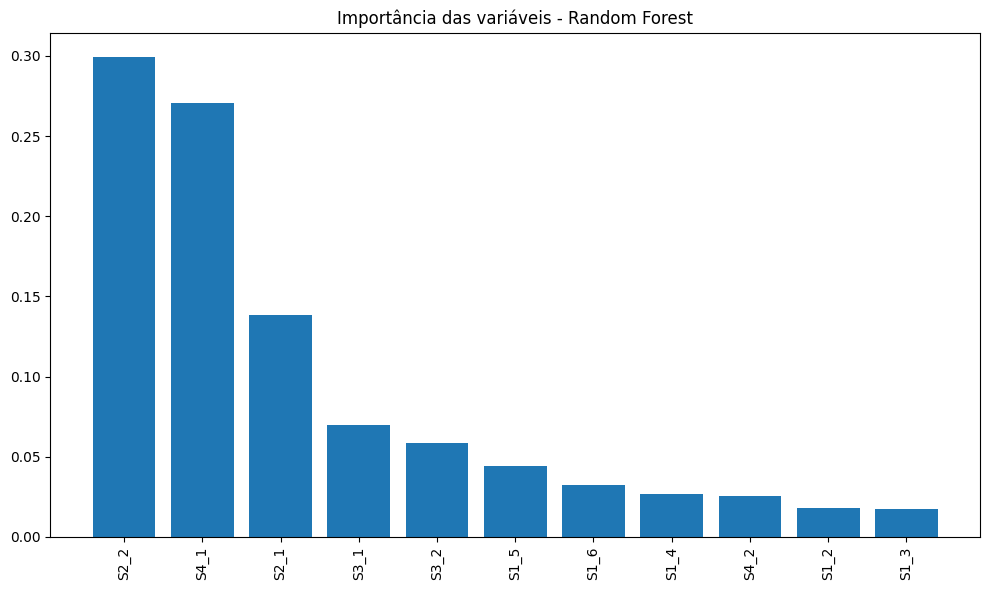

In [7]:
# Passo 5: Análise de importância das variáveis
importances = final_rf.feature_importances_
feat_names = x_train.columns
order = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[order], tick_label=feat_names[order])
plt.xticks(rotation=90)
plt.title('Importância das variáveis - Random Forest')
plt.tight_layout()
plt.show()

### Passo 6: Discussão dos resultados